# Smart Manufacturing Resource Efficiency Dataset Analysis

This notebook analyses manufacturing resource efficiency data to investigate sustainable manufacturing performance through energy consumption, recycled material usage, production output, and defect rate.

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Preparation

### Method

The dataset structure, data types, descriptive statistics, missing values, duplicates, and numerical consistency were examined. The Timestamp was converted to datetime format, while categorical variables were checked for their unique values.

### Decision

No missing values, duplicate records, or invalid numerical values were found. Therefore, no data removal or correction was required.

In [3]:
# Load Dataset + Structure + Data Types + Descriptive Statistics
df = pd.read_csv("smart_manufacturing_dataset.csv")

print("First Five Records:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

First Five Records:


,Timestamp,Machine ID,Material Category,Material Name,Quantity Used (kg),Recycled Material (%),Energy Consumption (kWh),Production Output (Units),Defect Rate (%)
0,2025-05-01 08:00:00,M002,Raw Material,Polypropylene,86.73,0.0,96.74,204,3.38
1,2025-05-01 08:05:00,M009,Raw Material,Cotton,54.77,0.0,91.24,338,2.53
2,2025-05-01 08:10:00,M001,Hazardous Material,Lead-Based Alloy,157.40,0.0,164.16,529,1.10
3,2025-05-01 08:15:00,M010,Process Additive,Industrial Oil,163.82,0.0,99.16,532,1.70
4,2025-05-01 08:20:00,M003,Intermediate Material,Plastic Resin,65.33,0.0,125.59,467,4.24



Dataset Shape:
(10000, 9)

Column Names:
['Timestamp', 'Machine ID', 'Material Category', 'Material Name', 'Quantity Used (kg)', 'Recycled Material (%)', 'Energy Consumption (kWh)', 'Production Output (Units)', 'Defect Rate (%)']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Timestamp                  10000 non-null  str    
 1   Machine ID                 10000 non-null  str    
 2   Material Category          10000 non-null  str    
 3   Material Name              10000 non-null  str    
 4   Quantity Used (kg)         10000 non-null  float64
 5   Recycled Material (%)      10000 non-null  float64
 6   Energy Consumption (kWh)   10000 non-null  float64
 7   Production Output (Units)  10000 non-null  int64  
 8   Defect Rate (%)            10000 non-null  float64
dtypes: float64(4), int64(1), str(4

,Quantity Used (kg),Recycled Material (%),Energy Consumption (kWh),Production Output (Units),Defect Rate (%)
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,124.534008,4.060385,140.111901,553.481500,2.526966
std,43.136723,10.908877,34.540921,260.877808,1.442364
min,50.010000,0.000000,80.010000,100.000000,0.000000
25%,87.215000,0.000000,110.647500,327.000000,1.290000
50%,124.250000,0.000000,140.315000,554.000000,2.540000
75%,161.752500,0.000000,169.877500,780.000000,3.780000
max,200.000000,49.960000,200.000000,1000.000000,5.000000


In [4]:
# Timestamp Transformation
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print("Start Date:", df["Timestamp"].min())
print("End Date:", df["Timestamp"].max())
print("Data Type:", df["Timestamp"].dtype)

Start Date: 2025-05-01 08:00:00
End Date: 2025-06-05 01:15:00
Data Type: datetime64[us]


In [5]:
# Missing Values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values:
Timestamp                    0
Machine ID                   0
Material Category            0
Material Name                0
Quantity Used (kg)           0
Recycled Material (%)        0
Energy Consumption (kWh)     0
Production Output (Units)    0
Defect Rate (%)              0
dtype: int64

Total Missing Values: 0


In [6]:
# Duplicate Records
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [7]:
# Data Consistency
print("Negative Quantity Used:",
      (df["Quantity Used (kg)"] < 0).sum())

print("Negative Energy Consumption:",
      (df["Energy Consumption (kWh)"] < 0).sum())

print("Negative Production Output:",
      (df["Production Output (Units)"] < 0).sum())

print("Recycled Material (%) outside 0-100:",
      ((df["Recycled Material (%)"] < 0) |
       (df["Recycled Material (%)"] > 100)).sum())

print("Defect Rate (%) outside 0-100:",
      ((df["Defect Rate (%)"] < 0) |
       (df["Defect Rate (%)"] > 100)).sum())

Negative Quantity Used: 0
Negative Energy Consumption: 0
Negative Production Output: 0
Recycled Material (%) outside 0-100: 0
Defect Rate (%) outside 0-100: 0


In [8]:
# Material Category Distribution
print("Number of Material Categories:",
      df["Material Category"].nunique())

print("\nMaterial Categories:")
print(df["Material Category"].unique())

print("\nRecords per Material Category:")
print(df["Material Category"].value_counts())

Number of Material Categories: 6

Material Categories:
<ArrowStringArray>
[         'Raw Material',    'Hazardous Material',      'Process Additive',
 'Intermediate Material',     'Finished Material',     'Recycled Material']
Length: 6, dtype: str

Records per Material Category:
Material Category
Raw Material             1758
Finished Material        1714
Intermediate Material    1681
Hazardous Material       1639
Recycled Material        1620
Process Additive         1588
Name: count, dtype: int64


In [9]:
# Check categorical variables

categorical_columns = [
    "Machine ID",
    "Material Category",
    "Material Name"
]

for column in categorical_columns:
    print(f"\n{column}")
    print("Number of unique values:", df[column].nunique())
    print("Missing values:", df[column].isnull().sum())
    print("Unique values:")
    print(df[column].unique())


Machine ID
Number of unique values: 10
Missing values: 0
Unique values:
<ArrowStringArray>
['M002', 'M009', 'M001', 'M010', 'M003', 'M005', 'M004', 'M006', 'M008',
 'M007']
Length: 10, dtype: str

Material Category
Number of unique values: 6
Missing values: 0
Unique values:
<ArrowStringArray>
[         'Raw Material',    'Hazardous Material',      'Process Additive',
 'Intermediate Material',     'Finished Material',     'Recycled Material']
Length: 6, dtype: str

Material Name
Number of unique values: 17
Missing values: 0
Unique values:
<ArrowStringArray>
[       'Polypropylene',               'Cotton',     'Lead-Based Alloy',
       'Industrial Oil',        'Plastic Resin',            'Packaging',
        'Circuit Board', 'Reprocessed Plastics',    'Machine Component',
             'Aluminum',             'Textiles',          'Sheet Metal',
              'Solvent',          'Scrap Steel',                'Steel',
              'Coolant',             'Catalyst']
Length: 17, dtype: str

In [10]:
# RQ1 Data Preparation Decision

print("========== RQ1: Data Preparation Decision ==========")

print("\n1. Missing Values:")
if df.isnull().sum().sum() == 0:
    print("No missing values found. No imputation or row removal is required.")
else:
    print("Missing values found. Further treatment is required.")

print("\n2. Duplicate Records:")
if df.duplicated().sum() == 0:
    print("No duplicate records found. No duplicate removal is required.")
else:
    print("Duplicate records found. Duplicate removal is required.")

print("\n3. Numerical Data Consistency:")
invalid_values = (
    (df["Quantity Used (kg)"] < 0).sum()
    + (df["Energy Consumption (kWh)"] < 0).sum()
    + (df["Production Output (Units)"] < 0).sum()
    + ((df["Recycled Material (%)"] < 0) |
       (df["Recycled Material (%)"] > 100)).sum()
    + ((df["Defect Rate (%)"] < 0) |
       (df["Defect Rate (%)"] > 100)).sum()
)

if invalid_values == 0:
    print("No invalid numerical values found. No correction is required.")
else:
    print("Invalid numerical values found. Further treatment is required.")

print("\n4. Timestamp:")
print("Timestamp has been converted from string to datetime format.")

print("\n5. Categorical Variables:")
print("Machine ID, Material Category, and Material Name were checked for")
print("unique values and missing values.")

========== RQ1: Data Preparation Decision ==========

1. Missing Values:
No missing values found. No imputation or row removal is required.

2. Duplicate Records:
No duplicate records found. No duplicate removal is required.

3. Numerical Data Consistency:
No invalid numerical values found. No correction is required.

4. Timestamp:
Timestamp has been converted from string to datetime format.

5. Categorical Variables:
Machine ID, Material Category, and Material Name were checked for
unique values and missing values.


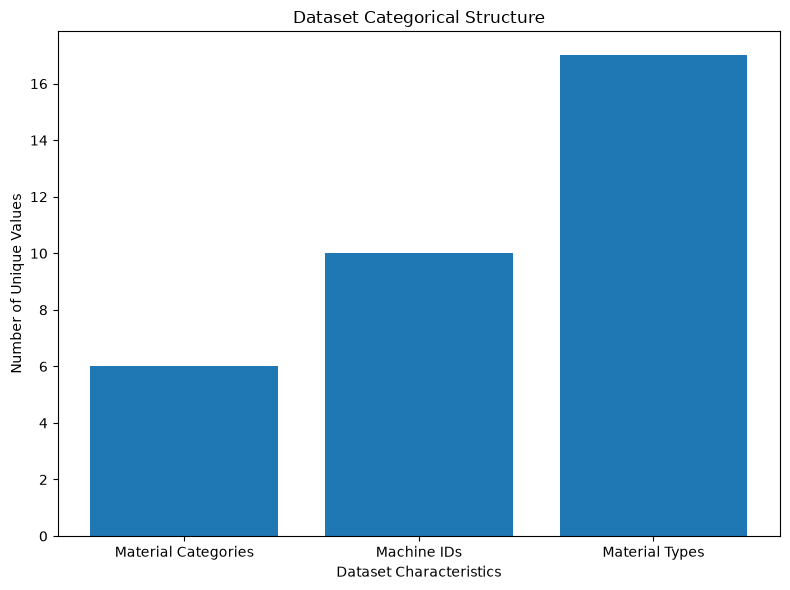

In [11]:
# RQ1 Visualisation – Dataset Categorical Structure

structure_data = {
    "Material Categories": df["Material Category"].nunique(),
    "Machine IDs": df["Machine ID"].nunique(),
    "Material Types": df["Material Name"].nunique()
}

fig = plt.figure(figsize=(8, 6))
ax = plt.axes()

ax.bar(
    structure_data.keys(),
    structure_data.values()
)

ax.set_xlabel("Dataset Characteristics")
ax.set_ylabel("Number of Unique Values")

ax.set_title(
    "Dataset Categorical Structure"
)

plt.tight_layout()

fig.savefig(
    "rq1_dataset_categorical_structure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The dataset was found to be structurally consistent and suitable for further analysis. No missing values, duplicate records, or invalid numerical values were identified, and the Timestamp was successfully converted to datetime format.

## RQ2 – Energy Consumption and Production Output Relationship

### Method

Pearson correlation analysis was used to measure the strength and direction of the relationship between Energy Consumption (kWh) and Production Output (Units). Pearson correlation was selected because both variables are numerical and the research question focuses on their linear relationship.

The correlation coefficient ranges from -1 to +1. Values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, while values close to 0 indicate little or no linear relationship.

In [12]:
# RQ2 Data Preparation
# Check variables required for correlation analysis

rq2_columns = [
    "Energy Consumption (kWh)",
    "Production Output (Units)"
]

print("RQ2 Variables:")
print(df[rq2_columns].describe().round(2))

print("\nMissing Values:")
print(df[rq2_columns].isnull().sum())

print("\nNon-positive Values:")

for column in rq2_columns:
    print(
        f"{column}:",
        (df[column] <= 0).sum()
    )

RQ2 Variables:
       Energy Consumption (kWh)  Production Output (Units)
count                  10000.00                   10000.00
mean                     140.11                     553.48
std                       34.54                     260.88
min                       80.01                     100.00
25%                      110.65                     327.00
50%                      140.32                     554.00
75%                      169.88                     780.00
max                      200.00                    1000.00

Missing Values:
Energy Consumption (kWh)     0
Production Output (Units)    0
dtype: int64

Non-positive Values:
Energy Consumption (kWh): 0
Production Output (Units): 0


In [13]:
# RQ2: Pearson Correlation Analysis

correlation = df["Energy Consumption (kWh)"].corr(
    df["Production Output (Units)"]
)

print("Pearson Correlation:")
print("Correlation coefficient:", round(correlation, 3))

Pearson Correlation:
Correlation coefficient: -0.002


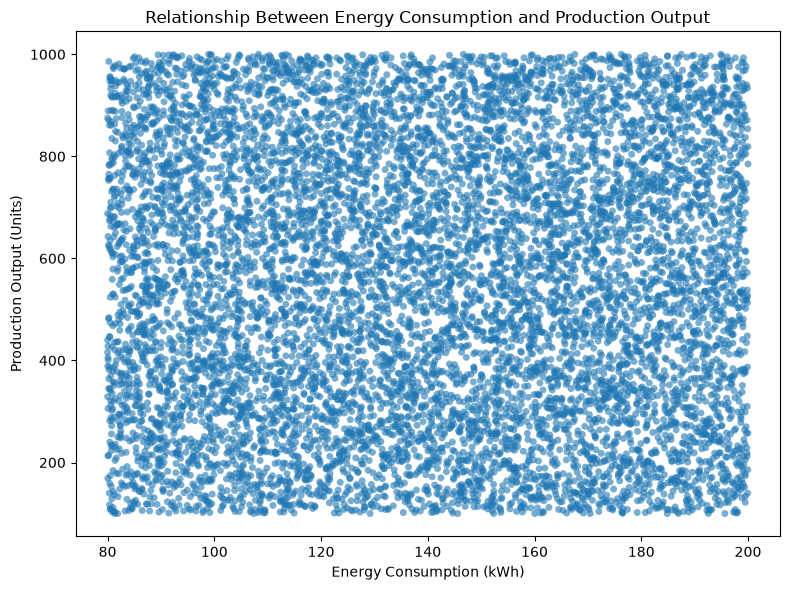

In [14]:
# RQ2: Scatter Plot

fig = plt.figure(figsize=(8, 6))
ax = plt.axes()

ax.scatter(
    df["Energy Consumption (kWh)"],
    df["Production Output (Units)"],
    s=25,
    alpha=0.6,
    edgecolors="none"
)

ax.set_xlabel("Energy Consumption (kWh)")
ax.set_ylabel("Production Output (Units)")

ax.set_title(
    "Relationship Between Energy Consumption and Production Output"
)

plt.tight_layout()

fig.savefig(
    "rq2_energy_output_relationship.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
print("========== RQ2 Visualisation Data ==========")

print("Number of observations:", len(df))

print("\nEnergy Consumption Range:")
print(
    df["Energy Consumption (kWh)"].min(),
    "to",
    df["Energy Consumption (kWh)"].max()
)

print("\nProduction Output Range:")
print(
    df["Production Output (Units)"].min(),
    "to",
    df["Production Output (Units)"].max()
)

print("\nPearson Correlation:")
print(
    df["Energy Consumption (kWh)"]
    .corr(df["Production Output (Units)"])
)

========== RQ2 Visualisation Data ==========
Number of observations: 10000

Energy Consumption Range:
80.01 to 200.0

Production Output Range:
100 to 1000

Pearson Correlation:
-0.0016605595880965693


### Interpretation

The Pearson correlation coefficient was -0.002, indicating an extremely weak negative linear relationship between Energy Consumption and Production Output. Since the value is close to zero, there is almost no linear relationship between the two variables in the dataset.

Correlation does not imply causation, and other factors such as machine utilisation, production scheduling, and production processes may affect production output.

## RQ3 – Material Category Comparison

### Method

The six material categories were compared using their mean Recycled Material (%), mean Production Output (Units), and mean Defect Rate (%). Grouped descriptive statistics were used because the research question focuses on comparing the average values across material categories.

Three bar charts were then created to visually communicate the differences between the categories.

In [16]:
# RQ3 Data Preparation
# Check variables required for material category comparison

rq3_columns = [
    "Material Category",
    "Recycled Material (%)",
    "Production Output (Units)",
    "Defect Rate (%)"
]

print("RQ3 Variables:")
display(df[rq3_columns].describe(include="all"))

print("\nMissing Values:")
print(df[rq3_columns].isnull().sum())

print("\nNumber of Records per Material Category:")
print(df["Material Category"].value_counts())

RQ3 Variables:


,Material Category,Recycled Material (%),Production Output (Units),Defect Rate (%)
count,10000,10000.000000,10000.000000,10000.000000
unique,6,NaN,NaN,NaN
top,Raw Material,NaN,NaN,NaN
freq,1758,NaN,NaN,NaN
mean,NaN,4.060385,553.481500,2.526966
std,NaN,10.908877,260.877808,1.442364
min,NaN,0.000000,100.000000,0.000000
25%,NaN,0.000000,327.000000,1.290000
50%,NaN,0.000000,554.000000,2.540000
75%,NaN,0.000000,780.000000,3.780000



Missing Values:
Material Category            0
Recycled Material (%)        0
Production Output (Units)    0
Defect Rate (%)              0
dtype: int64

Number of Records per Material Category:
Material Category
Raw Material             1758
Finished Material        1714
Intermediate Material    1681
Hazardous Material       1639
Recycled Material        1620
Process Additive         1588
Name: count, dtype: int64


In [17]:
# ============================================================
# RQ3 – Grouped Descriptive Statistics
# ============================================================

rq3_summary = df.groupby("Material Category").agg(
    Records=("Material Category", "size"),
    Average_Recycled_Material=("Recycled Material (%)", "mean"),
    Average_Production_Output=("Production Output (Units)", "mean"),
    Average_Defect_Rate=("Defect Rate (%)", "mean")
).round(2)

print("========== RQ3 Grouped Descriptive Statistics ==========")
display(rq3_summary)

========== RQ3 Grouped Descriptive Statistics ==========


,Records,Average_Recycled_Material,Average_Production_Output,Average_Defect_Rate
Material Category,,,,
Finished Material,1714,0.00,546.34,2.52
Hazardous Material,1639,0.00,558.93,2.52
Intermediate Material,1681,0.00,556.53,2.52
Process Additive,1588,0.00,560.98,2.53
Raw Material,1758,0.00,551.20,2.54
Recycled Material,1620,25.06,547.49,2.52


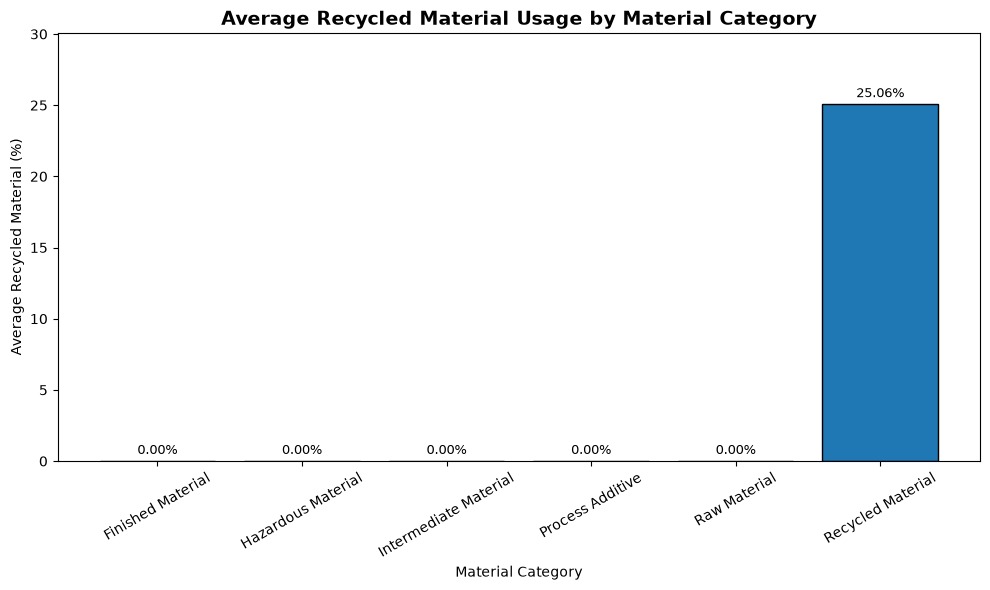

In [18]:
# ============================================================
# Figure 5(a) – Average Recycled Material Usage
# ============================================================

rq3_summary = df.groupby("Material Category").agg(
    Average_Recycled_Material=("Recycled Material (%)", "mean"),
    Average_Production_Output=("Production Output (Units)", "mean"),
    Average_Defect_Rate=("Defect Rate (%)", "mean")
)

category_order = [
    "Finished Material",
    "Hazardous Material",
    "Intermediate Material",
    "Process Additive",
    "Raw Material",
    "Recycled Material"
]

rq3_summary = rq3_summary.reindex(category_order)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    rq3_summary.index,
    rq3_summary["Average_Recycled_Material"],
    edgecolor="black"
)

ax.set_title(
    "Average Recycled Material Usage by Material Category",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Material Category")
ax.set_ylabel("Average Recycled Material (%)")

ax.set_ylim(
    0,
    rq3_summary["Average_Recycled_Material"].max() + 5
)

ax.tick_params(axis="x", rotation=30)

for bar in bars:
    value = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

fig.savefig(
    "rq3_recycled_material_usage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

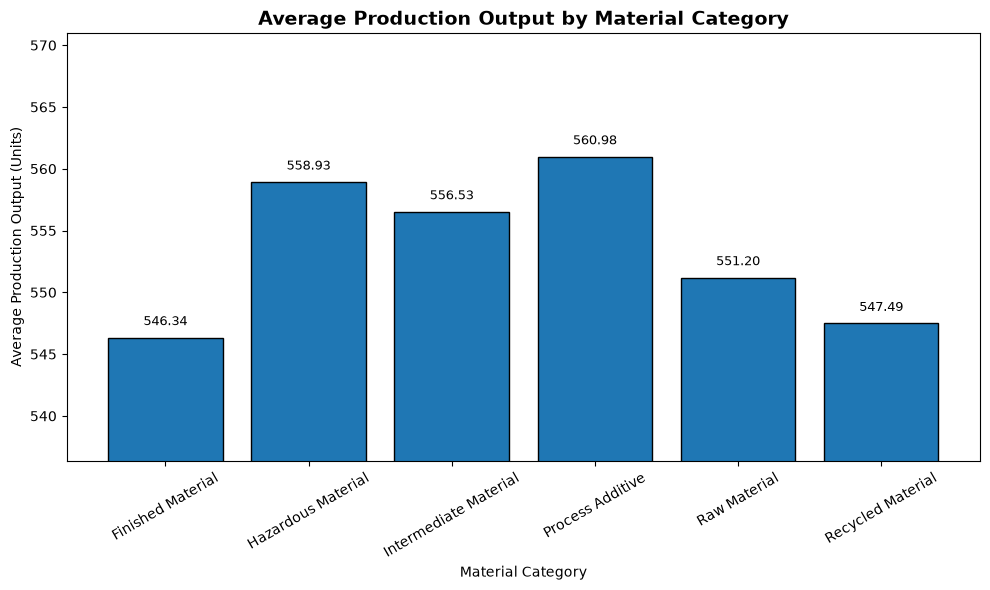

In [19]:
# ============================================================
# Figure 5(b) – Average Production Output
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    rq3_summary.index,
    rq3_summary["Average_Production_Output"],
    edgecolor="black"
)

ax.set_title(
    "Average Production Output by Material Category",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Material Category")
ax.set_ylabel("Average Production Output (Units)")

min_output = rq3_summary["Average_Production_Output"].min()
max_output = rq3_summary["Average_Production_Output"].max()

ax.set_ylim(
    min_output - 10,
    max_output + 10
)

ax.tick_params(axis="x", rotation=30)

for bar in bars:
    value = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

fig.savefig(
    "rq3_production_output.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

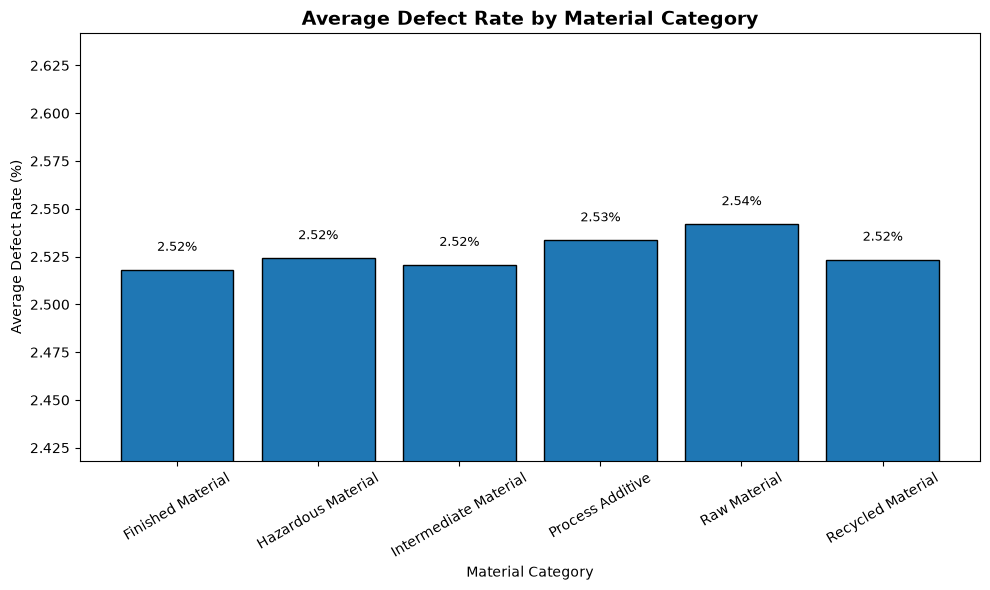

In [20]:
# ============================================================
# Figure 5(c) – Average Defect Rate
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    rq3_summary.index,
    rq3_summary["Average_Defect_Rate"],
    edgecolor="black"
)

ax.set_title(
    "Average Defect Rate by Material Category",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Material Category")
ax.set_ylabel("Average Defect Rate (%)")

min_defect = rq3_summary["Average_Defect_Rate"].min()
max_defect = rq3_summary["Average_Defect_Rate"].max()

ax.set_ylim(
    min_defect - 0.1,
    max_defect + 0.1
)

ax.tick_params(axis="x", rotation=30)

for bar in bars:
    value = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

fig.savefig(
    "rq3_defect_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The results show that recycled material usage differs substantially across the six material categories, while average production output and defect rate show relatively small differences.

The Recycled Material category has the highest average recycled material usage at 25.06%. Process Additive has the highest average production output at 560.98 units, while Raw Material has the highest average defect rate at 2.54%.